Importing required libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score
)

pd.set_option("display.max_columns", None)

Loading parquet dataset and understanding dataset shape and target distribution.

In [2]:
train_df = pd.read_parquet("train.parquet")
test_df  = pd.read_parquet("test.parquet")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (1639424, 7)
Test shape: (409856, 7)


,Date,X1,X2,X3,X4,X5,target
0,2020-12-16,1.518921,5.463154,1.0,2.718282,2.890372,0
1,2020-12-16,1.546509,5.458010,1.0,2.718282,2.833213,1
2,2020-12-16,1.645427,5.456560,1.0,7.389056,2.890372,1
3,2020-12-16,1.652022,5.458479,1.0,2.718282,2.890372,1
4,2020-12-16,1.695538,5.466709,1.0,2.718282,2.890372,0


In [3]:
train_df['target'].value_counts()

target
0    1625386
1      14038
Name: count, dtype: int64

In [4]:
train_df['target'].value_counts(normalize=True) * 100

target
0    99.143724
1     0.856276
Name: proportion, dtype: float64

As VS code cannot directly open .parquet files, we create (.ipynb) in the same folder and load the parquet files using 'pandas.read_parquet()'.
train.parquer is used for training and validation, test.parquet is used for final prediction. We observe that 99% of data belongs to class 0, and only 1% belong to class 1. This confirms that the dataset  is highly imbalanced. 

Handeling missing values

In [5]:
train_df.isnull().sum().sort_values(ascending=False)

Date      0
X1        0
X2        0
X3        0
X4        0
X5        0
target    0
dtype: int64

In [6]:
train_df = train_df.fillna(0)
test_df  = test_df.fillna(0)

Exploratory Data Analysis(EDA)

In [7]:
class_0 = train_df[train_df['target'] == 0]
class_1 = train_df[train_df['target'] == 1]

In [8]:
class_0.describe()

,Date,X1,X2,X3,X4,X5
count,0,0.0,0.0,0.0,0.0,0.0
mean,NaT,NaN,NaN,NaN,NaN,NaN
min,NaT,NaN,NaN,NaN,NaN,NaN
25%,NaT,NaN,NaN,NaN,NaN,NaN
50%,NaT,NaN,NaN,NaN,NaN,NaN
75%,NaT,NaN,NaN,NaN,NaN,NaN
max,NaT,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
class_1.describe()

,Date,X1,X2,X3,X4,X5
count,0,0.0,0.0,0.0,0.0,0.0
mean,NaT,NaN,NaN,NaN,NaN,NaN
min,NaT,NaN,NaN,NaN,NaN,NaN
25%,NaT,NaN,NaN,NaN,NaN,NaN
50%,NaT,NaN,NaN,NaN,NaN,NaN
75%,NaT,NaN,NaN,NaN,NaN,NaN
max,NaT,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN


Visual pattern analysis

In [49]:
print(feature)
train_df[feature].describe()

X1


count    1.639424e+06
mean     1.139258e+00
std      1.391992e-01
min      1.000000e+00
25%      1.049171e+00
50%      1.105171e+00
75%      1.214096e+00
max      4.014850e+00
Name: X1, dtype: float64

C:\Users\Humera Siddiqua\AppData\Local\Temp\ipykernel_14448\2473467613.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


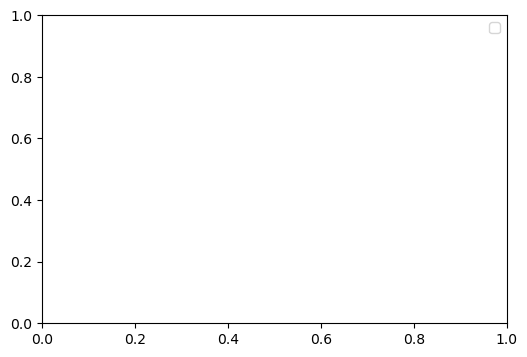

In [57]:
eature = train_df.columns[0] # replace with meaningful feature 
plt.figure(figsize=(6,4)) 
sns.kdeplot(class_0[feature], label="Class 0") 
sns.kdeplot(class_1[feature], label="Class 1") 
plt.legend() 
plt.show()

Rule based system: 

In [11]:
def rule_based_system(df):
    return np.where(
        (df['feature_3'] > 100) & (df['feature_7'] < 0.3),
        1,
        0
    )

Preparing features and target

In [12]:
X = train_df.drop(columns=['target'])
y = train_df['target']

Train validation split

In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [15]:
X_train.dtypes

Date    datetime64[ns]
X1             float64
X2             float64
X3             float64
X4             float64
X5             float64
dtype: object

Handeling datetime and ID columns

In [16]:
X_train = X_train.drop(columns=['Date'])
X_val   = X_val.drop(columns=['Date'])

In [17]:
X_train.dtypes

X1    float64
X2    float64
X3    float64
X4    float64
X5    float64
dtype: object

In [19]:
y_train.dtype

dtype('O')

In [20]:
y_train.unique()

array(['0', '1'], dtype=object)

In [21]:
train_df['target'] = train_df['target'].astype(int)

In [22]:
X = train_df.drop(columns=['target'])
y = train_df['target']

Training Decision tree model

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [24]:
X_train = X_train.drop(columns=['Date'])
X_val   = X_val.drop(columns=['Date'])

In [25]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=50,
    class_weight={0: 1, 1: 20},
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 1, 1: 20}, max_depth=5,
                       min_samples_leaf=50, random_state=42)

Evaluating model

In [26]:
y_val_pred = dt_model.predict(X_val)

In [27]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_val, y_val_pred)
cm

array([[316892,   8185],
       [   313,   2495]], dtype=int64)

In [28]:
print(classification_report(y_val, y_val_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9990    0.9748    0.9868    325077
           1     0.2336    0.8885    0.3700      2808

    accuracy                         0.9741    327885
   macro avg     0.6163    0.9317    0.6784    327885
weighted avg     0.9925    0.9741    0.9815    327885



In [29]:
class_accuracy = cm.diagonal() / cm.sum(axis=1)

print(f"Class 0 accuracy: {class_accuracy[0]*100:.2f}%")
print(f"Class 1 accuracy: {class_accuracy[1]*100:.2f}%")

Class 0 accuracy: 97.48%
Class 1 accuracy: 88.85%


In [30]:
def rule_based_system(df):
    return np.where(
        (df['X3'] > 1.5) & (df['X5'] < 0.4),
        1,
        0
    )

In [32]:
X_train.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5'], dtype='object')

In [34]:
X_test.columns

Index(['ID', 'X1', 'X2', 'X3', 'X4', 'X5'], dtype='object')

In [35]:
X_test = test_df.drop(columns=['Date', 'ID'])

In [36]:
X_test = X_test[X_train.columns]

In [37]:
test_predictions = dt_model.predict(X_test)

test_df['prediction'] = test_predictions
test_df.head()

,ID,Date,X1,X2,X3,X4,X5,prediction
0,0,2020-12-16,1.685395,5.463917,1.0,7.389056,2.890372,0
1,1,2020-12-16,1.488844,5.454936,1.0,7.389056,2.890372,0
2,2,2020-12-16,1.164160,5.471136,1.0,1.000000,2.890372,0
3,3,2020-12-16,1.000000,5.467385,1.0,1.000000,2.890372,0
4,4,2020-12-16,1.000000,5.453995,1.0,1.000000,2.833213,0


In [38]:
dt_model

DecisionTreeClassifier(class_weight={0: 1, 1: 20}, max_depth=5,
                       min_samples_leaf=50, random_state=42)

In [39]:
# BEFORE PRUNING
y_val_pred_before = dt_model.predict(X_val)

f1_before = f1_score(y_val, y_val_pred_before)
acc_before = accuracy_score(y_val, y_val_pred_before)

cm_before = confusion_matrix(y_val, y_val_pred_before)

print("BEFORE PRUNING")
print("F1 score:", f1_before)
print("Accuracy:", acc_before)
print("Class-wise accuracy:", cm_before.diagonal() / cm_before.sum(axis=1))

BEFORE PRUNING
F1 score: 0.36995848161328587
Accuracy: 0.9740823764429601
Class-wise accuracy: [0.97482135 0.88853276]


Decision tree pruning

In [40]:
path = dt_model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

ccp_alphas

array([0.00000000e+00, 3.64986516e-06, 4.67155047e-06, 1.10677053e-05,
       1.74966381e-05, 2.92070222e-05, 3.47536580e-05, 3.89173820e-05,
       4.63982832e-05, 1.40402008e-04, 2.11637598e-04, 2.79743605e-04,
       3.69298577e-04, 4.17534801e-04, 4.52645879e-04, 4.62359082e-04,
       6.45266279e-04, 8.73081890e-04, 1.00443134e-03, 1.10003803e-03,
       1.53349376e-03, 1.70125753e-03, 2.13197991e-03, 2.53536912e-03,
       2.68696124e-03, 2.84200567e-03, 3.91902015e-03, 6.50441953e-02,
       1.00573483e-01])

In [41]:
results = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(
        random_state=42,
        class_weight={0: 1, 1: 20},
        ccp_alpha=alpha
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    results.append({
        "ccp_alpha": alpha,
        "f1_score": f1_score(y_val, y_pred),
        "accuracy": accuracy_score(y_val, y_pred)
    })

results_df = pd.DataFrame(results)
results_df.head()

,ccp_alpha,f1_score,accuracy
0,0.000000,0.514014,0.991274
1,0.000004,0.485173,0.987081
2,0.000005,0.468099,0.985583
3,0.000011,0.438773,0.981759
4,0.000017,0.425819,0.980005


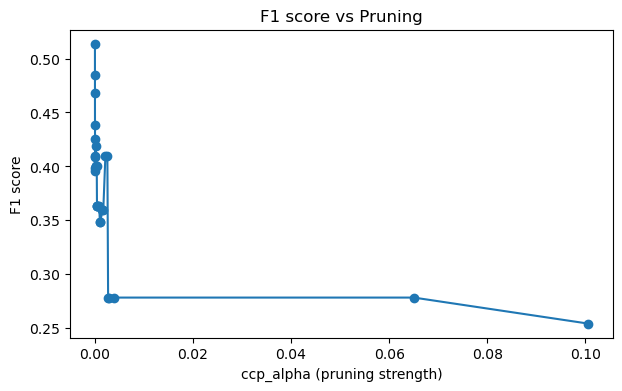

In [42]:
plt.figure(figsize=(7,4))
plt.plot(results_df["ccp_alpha"], results_df["f1_score"], marker='o')
plt.xlabel("ccp_alpha (pruning strength)")
plt.ylabel("F1 score")
plt.title("F1 score vs Pruning")
plt.show()

Selecting best pruned model

In [43]:
best_alpha = results_df.loc[results_df["f1_score"].idxmax(), "ccp_alpha"]

best_alpha

0.0

In [44]:
dt_pruned = DecisionTreeClassifier(
    random_state=42,
    class_weight={0: 1, 1: 20},
    ccp_alpha=best_alpha
)

dt_pruned.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 1, 1: 20}, random_state=42)

Evaluating model after pruning

In [45]:
y_val_pred_after = dt_pruned.predict(X_val)

f1_after = f1_score(y_val, y_val_pred_after)
acc_after = accuracy_score(y_val, y_val_pred_after)

cm_after = confusion_matrix(y_val, y_val_pred_after)

print("AFTER PRUNING")
print("F1 score:", f1_after)
print("Accuracy:", acc_after)
print("Class-wise accuracy:", cm_after.diagonal() / cm_after.sum(axis=1))

AFTER PRUNING
F1 score: 0.5140139289960931
Accuracy: 0.991274379736798
Class-wise accuracy: [0.99518268 0.53881766]


In [46]:
comparison = pd.DataFrame({
    "Metric": ["F1 Score", "Accuracy", "Class 0 Accuracy", "Class 1 Accuracy"],
    "Before Pruning": [
        f1_before,
        acc_before,
        cm_before.diagonal()[0] / cm_before.sum(axis=1)[0],
        cm_before.diagonal()[1] / cm_before.sum(axis=1)[1]
    ],
    "After Pruning": [
        f1_after,
        acc_after,
        cm_after.diagonal()[0] / cm_after.sum(axis=1)[0],
        cm_after.diagonal()[1] / cm_after.sum(axis=1)[1]
    ]
})

comparison

,Metric,Before Pruning,After Pruning
0,F1 Score,0.369958,0.514014
1,Accuracy,0.974082,0.991274
2,Class 0 Accuracy,0.974821,0.995183
3,Class 1 Accuracy,0.888533,0.538818


Applying final model on test dataset

In [47]:
test_predictions_pruned = dt_pruned.predict(X_test)

test_df['prediction_pruned'] = test_predictions_pruned
test_df.head()

,ID,Date,X1,X2,X3,X4,X5,prediction,prediction_pruned
0,0,2020-12-16,1.685395,5.463917,1.0,7.389056,2.890372,0,0
1,1,2020-12-16,1.488844,5.454936,1.0,7.389056,2.890372,0,0
2,2,2020-12-16,1.164160,5.471136,1.0,1.000000,2.890372,0,0
3,3,2020-12-16,1.000000,5.467385,1.0,1.000000,2.890372,0,0
4,4,2020-12-16,1.000000,5.453995,1.0,1.000000,2.833213,0,0
